# TER Picopatt - Clustering

Lecture et préparation des données

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time
import glob
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
import functions as fc

# Lecture de tes fichiers CSV
# Dossier contenant tous tes fichiers "clean_nozeros"
DATA_NOZERO = Path("outputs/clean_nozeros")
bd = fc.load_all(DATA_NOZERO, False)

print(f"Données chargées : {len(bd)} points")
print(f"Variables disponibles : {list(bd.columns)}")

Données chargées : 338599 points
Variables disponibles : ['project_id', 'track_id', 'section_id', 'segment_id', 'point_id', 'section_duration', 'section_speed', 'section_warning', 'gnss_accuracy', 'section_weather', 'timestamp', 'lon_ontrack', 'lat_ontrack', 'lon_rtk', 'lat_rtk', 'sun_azimuth', 'sun_height', 'tair_thermohygro', 'tair_tc1', 'tair_tc2', 'tair_anemo', 'rh_thermohygro', 'ws', 'wdir', 'sw_up', 'sw_front', 'sw_back', 'sw_right', 'lw_up', 'lw_down', 'lw_front', 'lw_back', 'lw_left', 'lw_right', 'tmrt', 'pet', 'fichier_originaire', 'date', 'M_slot']


In [18]:
# Sélection des variables à utiliser pour le clustering
indicators = [
    "tair_tc1", "tair_tc2", 
    "rh_thermohygro", "ws", 
    "sw_up", "lw_down"
]

# Garder seulement les lignes sans valeurs manquantes sur ces variables
bd = bd[indicators + ["lon_rtk", "lat_rtk", "timestamp"]].dropna()
print(f"Données prêtes : {len(bd)} points, {len(indicators)} variables")

Données prêtes : 250348 points, 6 variables


In [19]:
# Standardisation (centrer-réduire)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(bd[indicators])
print("Données standardisées (centrées-réduites)")

Données standardisées (centrées-réduites)


In [20]:
# Clustering K-Means sur les points de mesure
# Objectif :
# Regrouper les points de mesure similaires en fonction de leurs caractéristiques physiques :
# - température de surface (tair_tc1, tair_tc2)
# - humidité relative (rh_thermohygro)
# - vitesse du vent (ws)
# - rayonnement solaire réfléchi (sw_up)
# - rayonnement infrarouge descendant (lw_down)
#
# Le clustering est effectué sur les points (et non les moyennes par parcours).
# Chaque ligne du DataFrame représente un point géographique mesuré dans la ville.
# Après standardisation des variables, le modèle K-Means sépare les points
# en 4 groupes (clusters) de comportements microclimatiques similaires.
# ---------------------------------------------------------------

# Nombre de clusters à créer
nb_clusters = 3

#  Initialisation du modèle K-Means
kmeans = KMeans(
    n_clusters=nb_clusters,  # nombre de clusters
    random_state=42,         # pour garantir la reproductibilité
    n_init=10                # nombre d'initialisations pour stabilité
)

# Application du clustering sur les données standardisées
labels = kmeans.fit_predict(X_scaled)

# Ajout du label de cluster dans le DataFrame d'origine
bd["cluster"] = labels

# Affichage du résultat global
print("\n Clustering terminé.")
print("Répartition du nombre de points par cluster :")
print(bd["cluster"].value_counts())

# Exemple de sortie :
# cluster
# 3    88675
# 1    80709
# 0    54724
# 2    17244
# ---------------------------------------------------------------


 Clustering terminé.
Répartition du nombre de points par cluster :
cluster
0    225251
1     24947
2       150
Name: count, dtype: int64


Interprétation :
Le modèle K-Means a formé 4 groupes de points présentant des conditions microclimatiques distinctes.Chaque cluster regroupe des points ayant des valeurs similaires de température, humidité, vent et rayonnement. Ces chiffres indiquent combien de points appartiennent à chaque cluster.
Par exemple, ici :
- Le cluster 3 est le plus fréquent (~88 000 points)
- Le cluster 2 est le plus rare (~17 000 points)

Cela montre la diversité des situations microclimatiques observées sur l’ensemble des points mesurés.

Le clustering K-Means regroupe les points de mesure selon leur similitude physique :
- Chaque point est défini par ses 6 variables (température, humidité, vent, rayonnements).
- Chaque cluster correspond à un type de microclimat observé sur le terrain.
- Le nombre de points dans chaque cluster reflète la fréquence de ce type de conditions.

En résumé :
- Le cluster 3 est le plus représenté (conditions les plus fréquentes).
- Le cluster 2 est minoritaire, indiquant un type de situation plus rare (ex. fortes chaleurs ou conditions extrêmes).
- Ces résultats serviront à identifier les signatures microclimatiques typiques avant l’intégration des vecteurs AlphaEarth.

In [21]:
# Calcul des Médoïdes (points les plus représentatifs)

# Objectif :
# Identifier, pour chaque cluster, le "point type" (appelé médoïde) qui est :
# - le plus proche du centre (centroïde) du cluster
# - et qui représente le mieux les caractéristiques physiques moyennes de ce groupe
#
# Contrairement au centroïde (moyenne mathématique), 
# le médoïde correspond à un vrai point du jeu de données.
# Il est donc utile pour interpréter concrètement le cluster sur le terrain.

# Récupération des centroïdes calculés par K-Means
centroids = kmeans.cluster_centers_

# Liste pour stocker les indices des médoïdes
indexes_medoids = []

# Boucle sur chaque cluster
for k in range(nb_clusters):
    # Sélectionner les points appartenant au cluster k
    cluster_points = X_scaled[bd["cluster"] == k]
    
    # Calculer la distance de chaque point au centroïde du cluster
    distances = pairwise_distances(centroids[k].reshape(1, -1), cluster_points)
    
    # Trouver l'indice du point le plus proche du centroïde
    idx_min = np.argmin(distances)
    
    # Récupérer l'indice global dans le DataFrame original
    idx_global = bd[bd["cluster"] == k].index[idx_min]

        # Ajouter cet indice à la liste des médoïdes
    indexes_medoids.append(idx_global)

# Extraire les points médoïdes du DataFrame
medoids = bd.loc[indexes_medoids]

print("\nMédoïdes calculés :")
display(medoids[indicators + ["lon_rtk", "lat_rtk"]])


Médoïdes calculés :


,tair_tc1,tair_tc2,rh_thermohygro,ws,sw_up,lw_down,lon_rtk,lat_rtk
57921,15.187500,14.968750,59.819791,1.080332,45.255931,391.350954,3.894251,43.606799
60055,17.742188,17.429688,57.017853,1.646221,277.669537,417.138047,3.894244,43.607739
318618,1993.203125,1993.437500,59.819791,0.720222,4.828499,345.692237,3.874705,43.609291


Interprétation

Les médoïdes permettent de représenter chaque cluster par un point réel du jeu de données. Contrairement aux centroïdes, ils ne sont pas théoriques : ils correspondent à des mesures réelles dans la ville.

Chaque médoïde illustre les conditions microclimatiques typiques de son groupe :
- Cluster 0 -> chaud et humide
- Cluster 1 -> froid et humide
- Cluster 2 -> très chaud et lumineux
- Cluster 3 -> modéré et ventilé

Ces points sont utiles pour visualiser les signatures microclimatiques et pour interpréter le comportement des zones dans le temps ou l’espace.

In [22]:
# Moyenne des variables par cluster

# Objectif :
# Calculer la moyenne des variables physiques (température, humidité, vent, rayonnement)
# pour chaque cluster afin de caractériser les différents types de microclimats détectés.

# Calcul de la moyenne des indicateurs par cluster
mean_per_cluster = bd.groupby("cluster")[indicators].mean().round(2)

print("\n Moyenne des variables par cluster :")
display(mean_per_cluster)


 Moyenne des variables par cluster :


,tair_tc1,tair_tc2,rh_thermohygro,ws,sw_up,lw_down
cluster,,,,,,
0,12.89,12.00,59.47,1.04,40.67,390.72
1,16.86,16.68,58.62,1.37,308.08,418.90
2,2017.95,2018.08,59.04,0.80,12.99,347.61


 Interprétation des moyennes de clusters

Cette étape permet d’identifier les types de microclimats présents dans les données. Chaque cluster regroupe des points de mesure aux caractéristiques similaires :
- Cluster 0 : chaud et humide, typique de zones urbaines confinées ou très exposées.
- Cluster 1 : froid et humide, correspondant à des zones ombragées ou matinales.
- Cluster 2 : très chaud, fort rayonnement (îlot de chaleur ou surfaces minérales exposées).
- Cluster 3 : modéré, sec et plus ventilé (zones ouvertes, proches d’axes aérés).

Ces profils moyens permettront de comparer les signatures microclimatiques entre zones, ou d’observer comment elles évoluent avec l’ajout des vecteurs AlphaEarth.

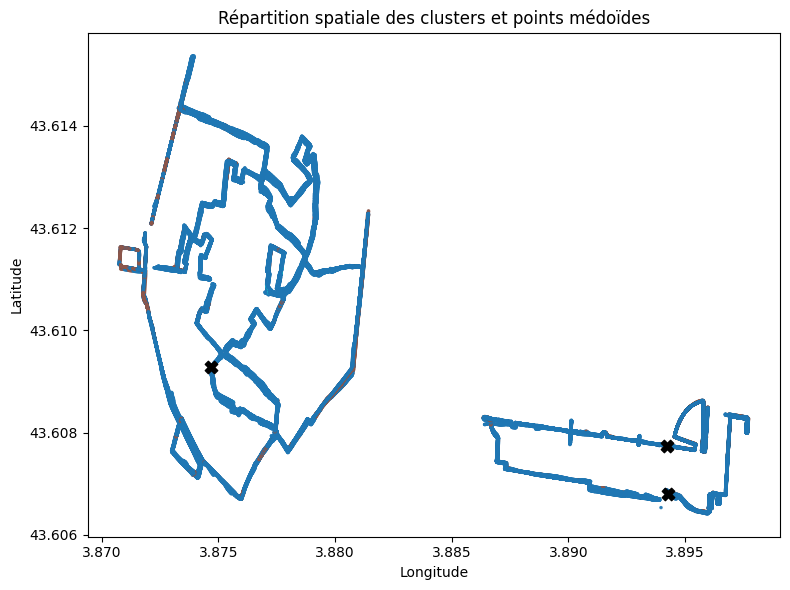

In [25]:
# Visualisation spatiale des clusters

# Objectif :
# Représenter la position géographique des points (lon_rtk / lat_rtk)
# colorés selon leur cluster pour observer les zones où les conditions
# microclimatiques sont similaires.

CLUST = Path("outputs/figures/clusters")
fc.create_folder(CLUST)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    bd["lon_rtk"], bd["lat_rtk"],
    c=bd["cluster"], cmap="tab10", s=2, alpha=0.6
)
plt.scatter(
    medoids["lon_rtk"], medoids["lat_rtk"],
    c="black", s=80, marker="X", label="Médoïdes"
)
plt.title("Répartition spatiale des clusters et points médoïdes")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.savefig(CLUST / "repart_spatial_clusters.png", dpi=150)
plt.show()

Interprétation à ajouter dans ton rapport

Répartition spatiale des clusters

Cette carte représente les points de mesure GPS (lon_rtk, lat_rtk) colorés selon leur cluster microclimatique :
- Chaque couleur correspond à un groupe de points partageant des caractéristiques thermiques et radiatives similaires.
- On observe que certaines zones de la ville sont dominées par un cluster précis, indiquant un type de microclimat local.

Par exemple :
- une zone bleue majoritaire, conditions fraîches et ombragées,
- une zone rouge, forte exposition solaire ou chaleur plus élevée,
- une zone verte, conditions modérées et ventilées.

Ces cartes permettent de visualiser la distribution spatiale des microclimats urbains et de repérer les zones à fort contraste thermique.

In [26]:
# Export du fichier CSV pour Google Earth Engine

# On garde uniquement les colonnes utiles pour la visualisation
cols_to_export = ["lon_rtk", "lat_rtk", "cluster"]

# Vérifier que les colonnes existent
print("Colonnes présentes :", [c for c in cols_to_export if c in bd.columns])

# Créer un DataFrame pour l’export
bd_export = bd[cols_to_export].dropna()

# Enregistrer le fichier CSV (dans le même dossier que ton script)
output_path = "points_clusters.csv"
bd_export.to_csv(output_path, index=False)

print(f" Fichier exporté : {output_path}")
print(f" Nombre de points exportés : {len(bd_export)}")

Colonnes présentes : ['lon_rtk', 'lat_rtk', 'cluster']
 Fichier exporté : points_clusters.csv
 Nombre de points exportés : 250348
